In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Libraries imported successfully')

Libraries imported successfully


In [46]:
#Load the dataset

df=pd.read_csv("D:\Joya\Athlete_Training_Recovery_Tracker\data\Athlete_Training_Recovery_Tracker_Dataset.csv")
print("Shapes:",df.shape)
print("First 5 Rows","\n",df.head(5))

Shapes: (1000, 11)
First 5 Rows 
   Athlete_ID Sport_Type  Training_Hours  Training_Intensity  Sleep_Hours  \
0      A0001  Badminton            4.49                   2          5.0   
1      A0002  Athletics            3.68                   6          5.2   
2      A0003    Cricket            2.55                   5          7.4   
3      A0004  Badminton            5.07                  10          8.6   
4      A0005     Tennis            4.42                   9          6.0   

   Nutrition_Score  Fatigue_Level  Recovery_Index  Performance_Score  \
0               78              9              93                 68   
1               68              9              52                 94   
2               68              7              88                 93   
3               51             10              76                 56   
4               90              3              82                 93   

  Injury_Risk        Date  
0        High  2025-01-01  
1         Low  2025-

<>:3: SyntaxWarning: "\J" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\J"? A raw string is also an option.
<>:3: SyntaxWarning: "\J" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\J"? A raw string is also an option.
C:\Users\joyaj\AppData\Local\Temp\ipykernel_22180\3209999844.py:3: SyntaxWarning: "\J" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\J"? A raw string is also an option.
  df=pd.read_csv("D:\Joya\Athlete_Training_Recovery_Tracker\data\Athlete_Training_Recovery_Tracker_Dataset.csv")


In [47]:
#Data Cleaning and Feature Engineering

In [48]:
#Making a copy to work with

df_clean=df.copy()

#Checking missing values
missing=df_clean.isnull().sum()
print(missing[missing>0])

if missing.sum()==0:
    print("No missing values")
else:
    print("Total Missing Values",{missing.sum()})

Series([], dtype: int64)
No missing values


In [49]:
#convert Date to datetime
df_clean['Date']=pd.to_datetime(df_clean['Date'])



In [54]:
#Calculating Training Load(Training Load=Duration*Intensity)
df_clean['Training_Load']=df_clean['Training_Hours']*df_clean['Training_Intensity']
display(df_clean.head())


,Athlete_ID,Sport_Type,Training_Hours,Training_Intensity,Sleep_Hours,Nutrition_Score,Fatigue_Level,Recovery_Index,Performance_Score,Injury_Risk,Date,Training_Load,Wellness Score,Acute_Load,Chronic_Load,ACWR,Risk_Level,Avg_Training_Load,Recent_Load,Load_Ratio
0,A0001,Badminton,4.49,2,5.0,78,9,93,68,High,2025-01-01,8.98,73.666667,8.98,NaN,1.0,Optimal,8.98,8.98,1.0
1,A0002,Athletics,3.68,6,5.2,68,9,52,94,Low,2025-01-02,22.08,57.333333,22.08,NaN,1.0,Optimal,22.08,22.08,1.0
2,A0003,Cricket,2.55,5,7.4,68,7,88,93,Medium,2025-01-03,12.75,76.666667,12.75,NaN,1.0,Optimal,12.75,12.75,1.0
3,A0004,Badminton,5.07,10,8.6,51,10,76,56,Low,2025-01-04,50.70,71.000000,50.70,NaN,1.0,Optimal,50.70,50.70,1.0
4,A0005,Tennis,4.42,9,6.0,90,3,82,93,Low,2025-01-05,39.78,77.333333,39.78,NaN,1.0,Optimal,39.78,39.78,1.0


In [56]:
print("=== KEY BUSINESS INSIGHTS ===\n")

print("1. Average Training Load by Sport:")
print(df_clean.groupby('Sport_Type')['Training_Load'].mean().round(2).sort_values(ascending=False))

print("2. Injury Risk Distribution (%):")
print(df_clean['Injury_Risk'].value_counts(normalize=True).round(3)*100)

print("3. Average Performance by Injury Risk:")
print(df_clean.groupby('Injury_Risk')['Performance_Score'].mean().round(2))

print("4. Correlation Matrix:")
corr_matrix = df_clean[['Training_Load', 'Training_Intensity', 'Fatigue_Level', 
                       'Recovery_Index', 'Performance_Score']].corr().round(2)
print(corr_matrix)

=== KEY BUSINESS INSIGHTS ===

1. Average Training Load by Sport:
Sport_Type
Cricket       20.31
Swimming      20.23
Hockey        19.86
Badminton     19.55
Basketball    19.36
Athletics     18.85
Tennis        18.06
Football      17.79
Name: Training_Load, dtype: float64
2. Injury Risk Distribution (%):
Injury_Risk
Low       70.6
Medium    19.9
High       9.5
Name: proportion, dtype: float64
3. Average Performance by Injury Risk:
Injury_Risk
High      76.06
Low       74.35
Medium    75.21
Name: Performance_Score, dtype: float64
4. Correlation Matrix:
                    Training_Load  Training_Intensity  Fatigue_Level  \
Training_Load                1.00                0.73          -0.01   
Training_Intensity           0.73                1.00          -0.00   
Fatigue_Level               -0.01               -0.00           1.00   
Recovery_Index              -0.01                0.00          -0.01   
Performance_Score            0.01                0.00           0.07   

         

In [57]:
#Visualisation

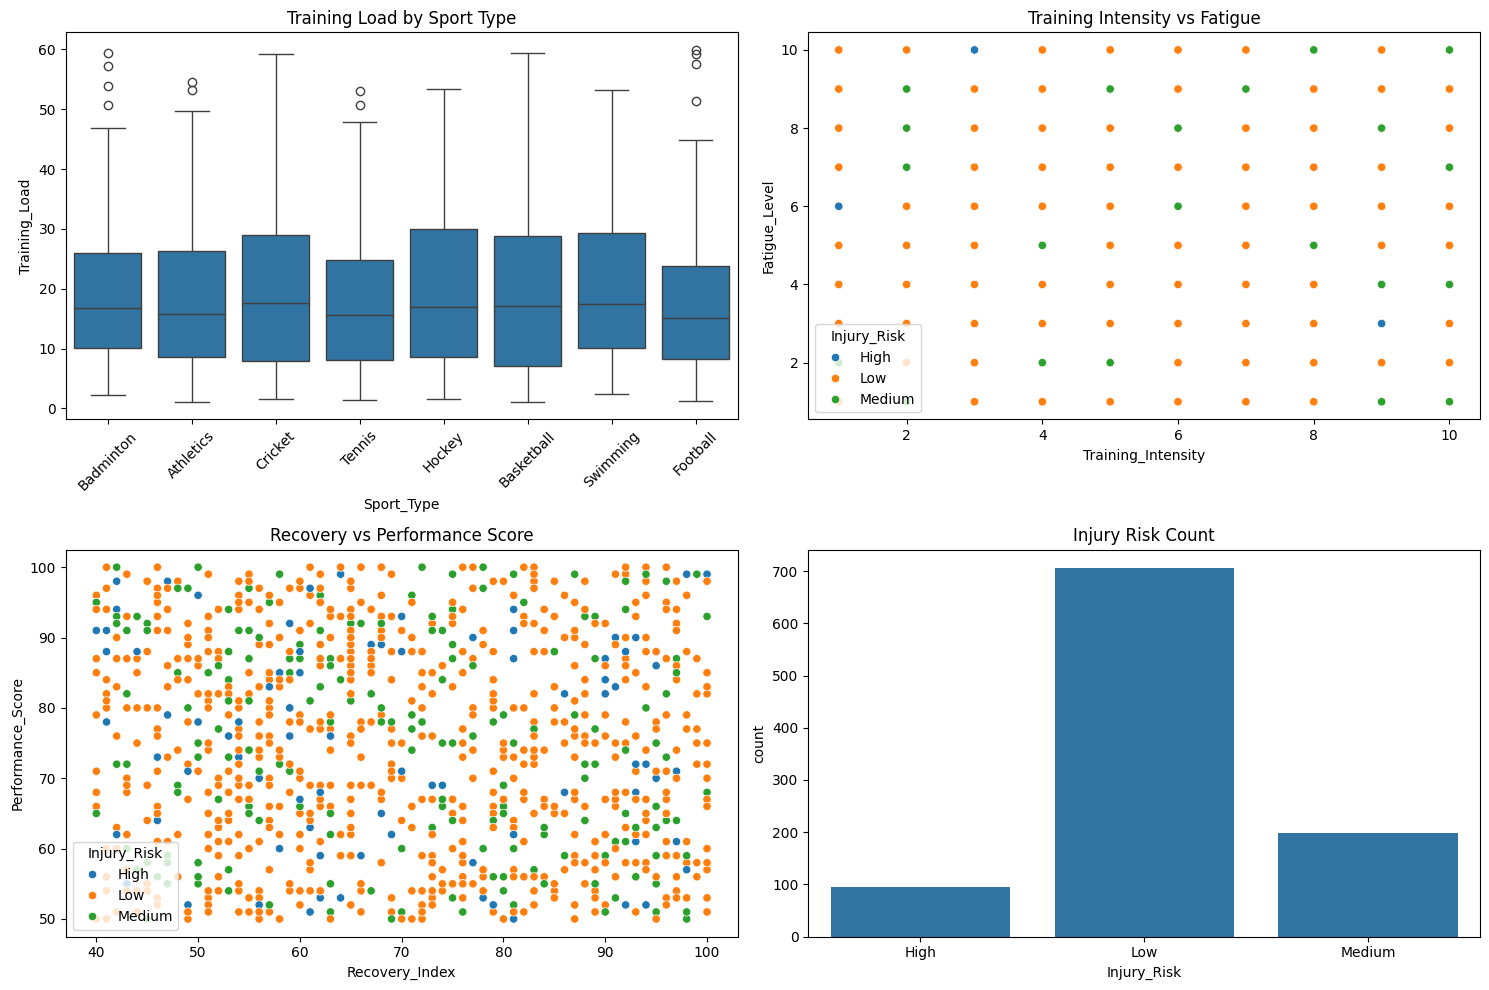

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(x='Sport_Type', y='Training_Load', data=df_clean, ax=axes[0,0])
axes[0,0].set_title('Training Load by Sport Type')
axes[0,0].tick_params(axis='x', rotation=45)

sns.scatterplot(x='Training_Intensity', y='Fatigue_Level', hue='Injury_Risk', 
                data=df_clean, ax=axes[0,1])
axes[0,1].set_title('Training Intensity vs Fatigue')

sns.scatterplot(x='Recovery_Index', y='Performance_Score', hue='Injury_Risk', 
                data=df_clean, ax=axes[1,0])
axes[1,0].set_title('Recovery vs Performance Score')

sns.countplot(x='Injury_Risk', data=df_clean, ax=axes[1,1])
axes[1,1].set_title('Injury Risk Count')

plt.tight_layout()
plt.show()